In [2]:
from matplotlib import pyplot as plt
from glob import glob
import numpy as np
from collections import defaultdict
import librosa.display
import random

Loading the spectrograms from both classes

In [36]:
class0 = glob("../preprocessing_pipeline/spectogram_data/Class0/*")
class1 = glob("../preprocessing_pipeline/spectogram_data/Class1/*")
noise = glob("../preprocessing_pipeline/spectogram_data/Random_Noise/*")

class0_specs = []
class1_specs = []
class0_per_speaker = defaultdict(int)
class0_per_noise_type = defaultdict(int)
class1_per_speaker = defaultdict(int)

for person in class0:
    person_path = glob(f'{person}/*.npz')
    for path in person_path:
        specs = np.load(path, allow_pickle=True)
        class0_specs.extend(specs['X'])
        class0_per_speaker[person] += len(specs['X'])

random_noise_specs = []

for no in noise:
    no_path = glob(f'{no}/*.npz')
    for path in no_path:
        specs = np.load(path, allow_pickle=True)
        class0_specs.extend(specs['X'])
        random_noise_specs.extend(specs['X'])
        class0_per_noise_type[no] += len(specs['X'])


for person in class1:
    person_path = glob(f'{person}/*.npz')
    for path in person_path:
        specs = np.load(path, allow_pickle=True)
        class1_specs.extend(specs['X'])
        class1_per_speaker[person] += len(specs['X'])


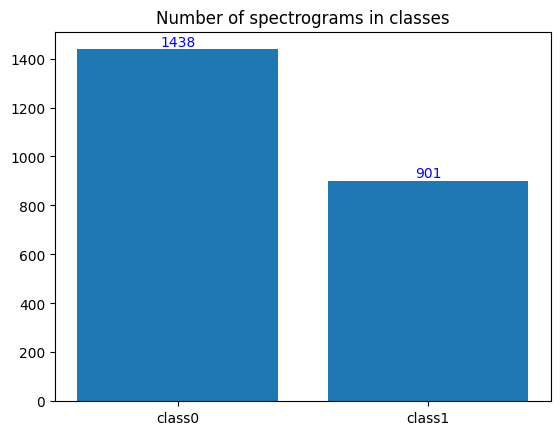

In [4]:
class0_count = len(class0_specs)
class1_count = len(class1_specs)

fig, ax = plt.subplots()
x_positions = [0, 1]
bars = ax.bar(['class0', 'class1'], [class0_count, class1_count])

ax.bar_label(bars, label_type='edge', color='blue')
ax.title.set_text('Number of spectrograms in classes')
plt.show()



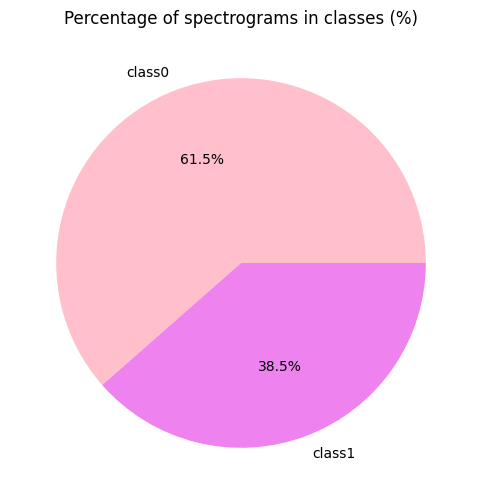

In [5]:
plt.figure(figsize=(6, 6))
class0_count = len(class0_specs)
class1_count = len(class1_specs)
plt.pie([class0_count, class1_count], labels=['class0', 'class1'], colors=['pink', 'violet'], autopct='%1.1f%%')

plt.title('Percentage of spectrograms in classes (%)')
plt.show()

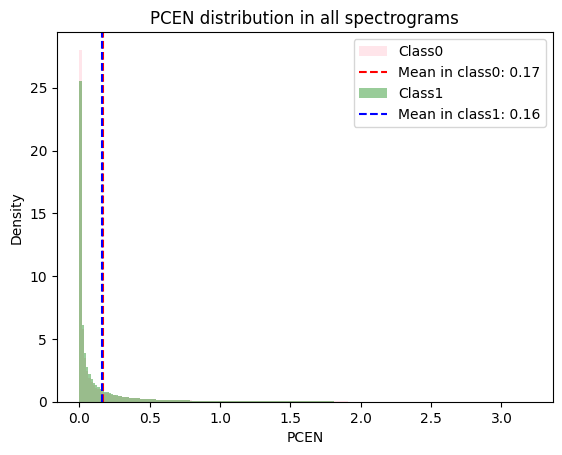

In [58]:
fig, axes = plt.subplots(1)
class0_values = np.concatenate([spec.flatten() for spec in class0_specs])
class1_values = np.concatenate([spec.flatten() for spec in class1_specs])

all_values = np.concatenate([class0_values, class1_values])
bins = np.linspace(all_values.min(), all_values.max(), 201)

axes.hist(class0_values, bins=bins, alpha=0.4, color='pink', label='Class0', density=True)
axes.axvline(np.mean(class0_values), color='red', linestyle='--', label=f'Mean in class0: {np.mean(class0_values):.2f}')
axes.hist(class1_values, bins=bins, alpha=0.4, color='green', label='Class1', density=True)
axes.axvline(np.mean(class1_values), color='blue', linestyle='--', label=f'Mean in class1: {np.mean(class1_values):.2f}')
axes.set_title('PCEN distribution in all spectrograms')
axes.set_xlabel('PCEN')
axes.set_ylabel('Density')
axes.legend()

plt.show()

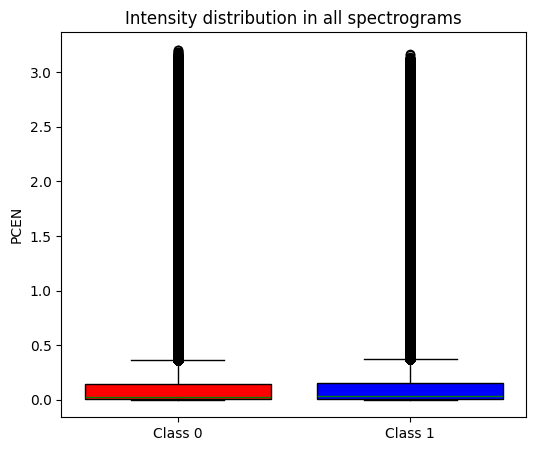

In [50]:
fig, ax = plt.subplots(figsize=(6, 5))
# all values from spectrograms from class 0 and class 1
bp = ax.boxplot([class0_values.flatten(), class1_values.flatten()],
                tick_labels=['Class 0', 'Class 1'],
                patch_artist=True,
                widths=0.8,
                medianprops=dict(color='green'))
#
bp['boxes'][0].set_facecolor('red')
bp['boxes'][1].set_facecolor('blue')

ax.set_title('Intensity distribution in all spectrograms')
ax.set_ylabel('PCEN')

plt.show()

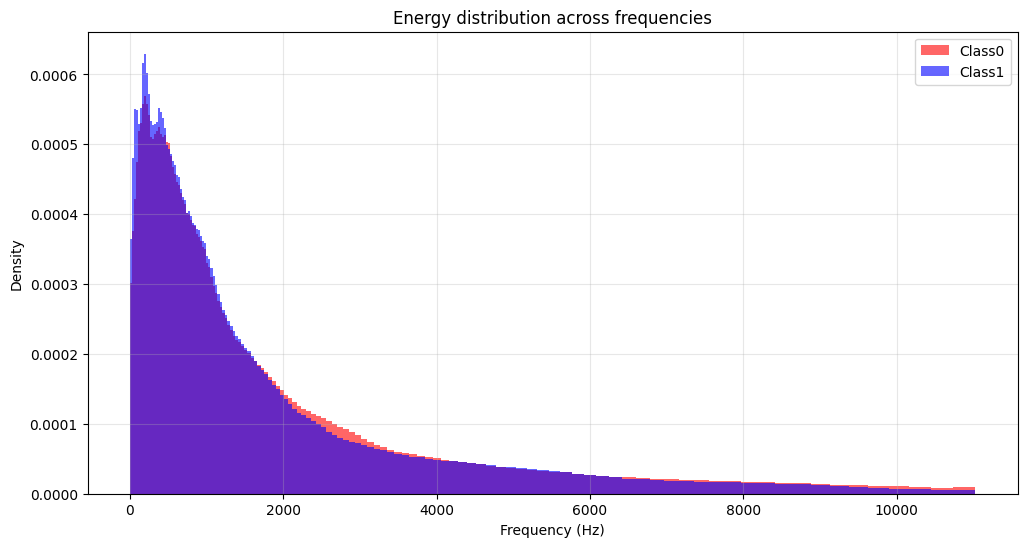

In [57]:
class0_freq_energy = np.zeros(128)
class1_freq_energy = np.zeros(128)

for spec in class0_specs:
    # Sum across time for each frequency
    class0_freq_energy += np.sum(spec, 1)

for spec in class1_specs:
    class1_freq_energy += np.sum(spec, 1)

#If None, use fmax = sr / 2.0 -> we did not specify when creating spectrograms
mel_freqs = librosa.mel_frequencies(n_mels=128, fmin=0.0, fmax=22050/2)


plt.figure(figsize=(12, 6))
plt.hist(mel_freqs, bins=mel_freqs, weights=class0_freq_energy,
         alpha=0.6, color='red', label='Class0', density=True)
plt.hist(mel_freqs, bins=mel_freqs, weights=class1_freq_energy,
         alpha=0.6, color='blue', label='Class1', density=True)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Density')
plt.legend()
plt.title('Energy distribution across frequencies')
plt.show()

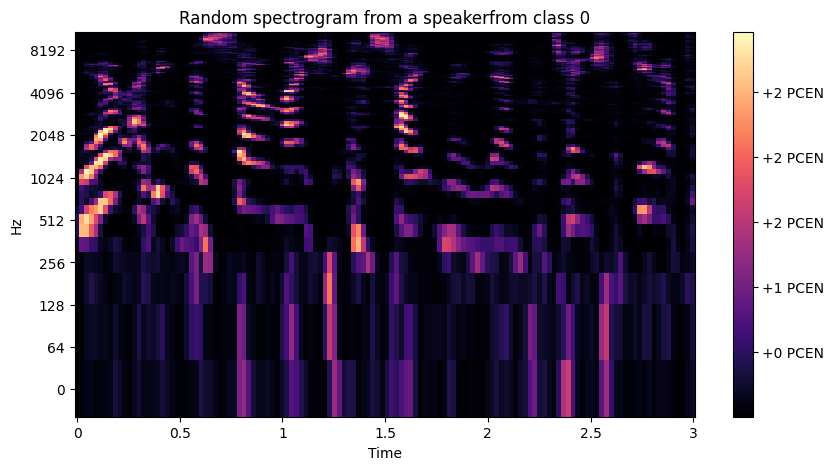

In [51]:
fig, ax = plt.subplots(figsize=(10,5))
img = librosa.display.specshow(class0_specs[0], x_axis='time', y_axis='log', ax=ax)
fig.colorbar(img, ax=ax, format='%+2.f PCEN')
ax.set_title("Random spectrogram from a speakerfrom class 0")
plt.show()

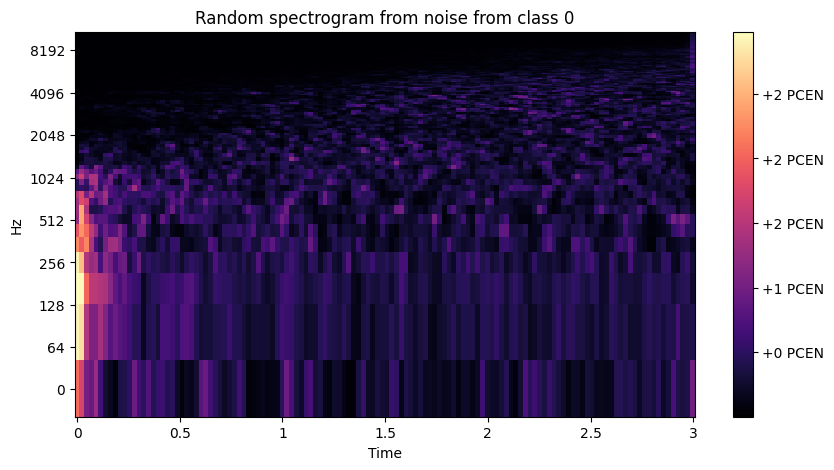

In [52]:
fig, ax = plt.subplots(figsize=(10,5))
img = librosa.display.specshow(random_noise_specs[0], x_axis='time', y_axis='log', ax=ax)
fig.colorbar(img, ax=ax, format='%+2.f PCEN')
ax.set_title("Random spectrogram from noise from class 0")
plt.show()

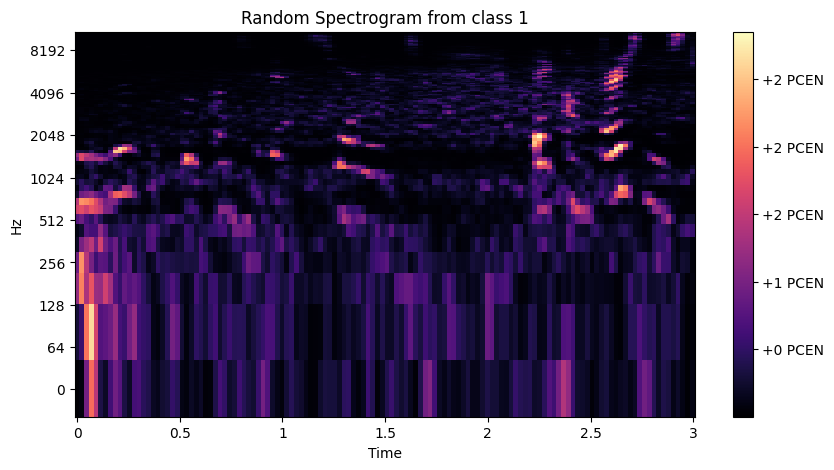

In [53]:
fig, ax = plt.subplots(figsize=(10,5))
img = librosa.display.specshow(class1_specs[0], x_axis='time', y_axis='log', ax=ax)
fig.colorbar(img, ax=ax, format='%+2.f PCEN')
ax.set_title("Random Spectrogram from class 1")
plt.show()

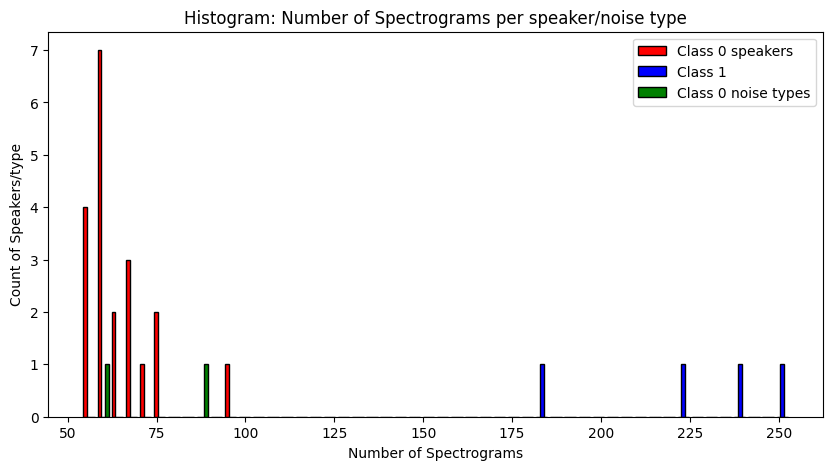

In [12]:
#to check if the quality of the recordings was so bad for a speaker that because of silence removal we didn't get that many spectograms
plt.figure(figsize=(10,5))


plt.hist(
    [list(class0_per_speaker.values()), list(class1_per_speaker.values()), list(class0_per_noise_type.values())],
    bins=50,
    color=["red", "blue", "green"],
    label=["Class 0 speakers", "Class 1", "Class 0 noise types"],
    edgecolor='black'
)

plt.title("Histogram: Number of Spectrograms per speaker/noise type")
plt.xlabel("Number of Spectrograms")
plt.ylabel("Count of Speakers/type")
plt.legend()
plt.show()

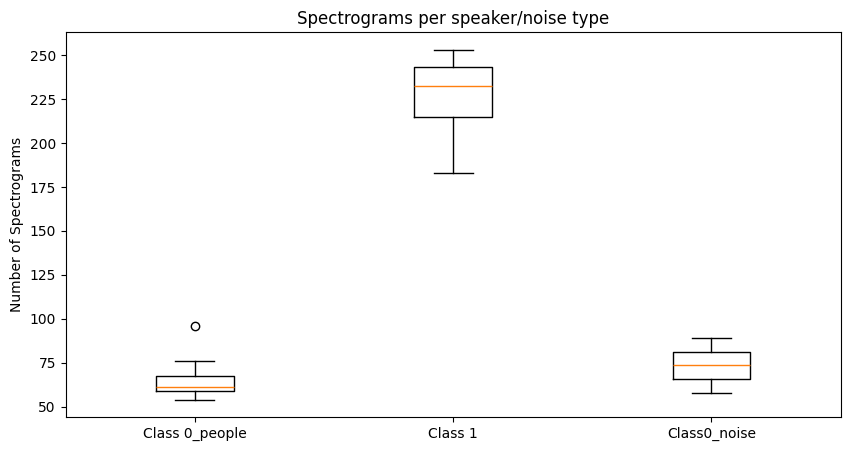

In [13]:
plt.figure(figsize=(10,5))

plt.boxplot([list(class0_per_speaker.values()), list(class1_per_speaker.values()), list(class0_per_noise_type.values())], tick_labels=["Class 0_people", "Class 1", "Class0_noise"])

plt.title("Spectrograms per speaker/noise type")
plt.ylabel("Number of Spectrograms")
plt.show()

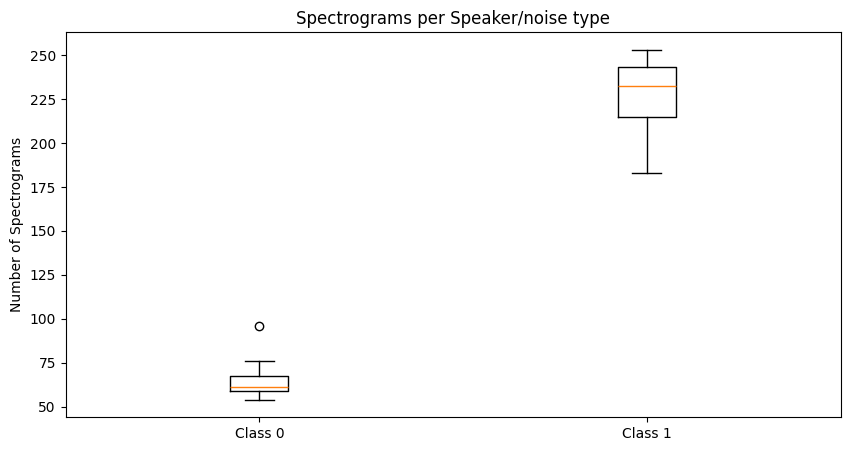

In [14]:
plt.figure(figsize=(10,5))

plt.boxplot([list(class0_per_speaker.values()), list(class1_per_speaker.values())], tick_labels=["Class 0", "Class 1"])

plt.title("Spectrograms per Speaker/noise type")
plt.ylabel("Number of Spectrograms")
plt.show()